# Tarea 7 

**Objetivo**: Resuelve el siguiente caso práctico y entrega un html con tu procedimiento y respuestas. A continuación se muestran los puntos por resolver.
 

# 1) Función de Métricas de Desempeño.

Genera una función en python que reciba un data frame con la evolución histórica de n cantidad de estrategías de inversión y calcule todas las métricas de desempeño vistas en las dos clases anteriores (Rendimiento, Volatilidad, Ratio de Sharpe, Downside, Upside, Omega, Beta, Alfa de Jensen, Ratio de Treynor, Ratio de Sortino). (20%)

In [50]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

from scipy.optimize import minimize

In [51]:
pd.options.display.float_format = "{:,.4f}".format

In [52]:
def metricas_desempeño(
    df_strategies : pd.DataFrame, 
    threshold : float,
    benchmark : pd.DataFrame
    ) -> pd.DataFrame:
    
    benchmark_name = benchmark.columns[0]
    
    df_metrics = pd.DataFrame([
        "Rendimiento esperado", 
        "Rendimiento realizado",
        "Volatilidad",
        "Ratio de sharpe",
        "Downside risk",
        "Upside risk",
        "Omega",
        "Beta",
        "Alpha de Jensen",
        "Ratio de Treynor",
        "Ratio de Sortino"
        ])
    
    strategies_returns = df_strategies.pct_change().dropna()
    
    df_metrics["Rendimiento esperado"] = strategies_returns.mean()
    
    df_metrics["Rendimiento realizado"] = strategies_returns.iloc[-1] /  strategies_returns.iloc[0] - 1
    
    df_metrics["Volatilidad"] = strategies_returns.std()
    
    df_metrics["Ratio de sharpe"] = (df_metrics["Rendimiento esperado"] - threshold)/df_metrics["Volatilidad"]
    
    df_metrics["Downside risk"] = strategies_returns[strategies_returns < 0].fillna(0).std()
    
    df_metrics["Upside risk"] = strategies_returns[strategies_returns > 0].fillna(0).std()
    
    df_metrics["Omega"] = df_metrics["Upside risk"] / df_metrics["Downside risk"]
    
    df = pd.concat([df_metrics, df_strategies], axis = 1)
    
    benchmark_cov = df.cov()[benchmark_name]
    
    df_metrics["Beta"] = benchmark_cov / benchmark.var()
    
    return df_metrics
    

# 2) Backtesting de Portafolio

Asume que quieres invertir en un portafolio compuesto por las siguientes acciones mexicanas: LIVEPOLC1.MX, KOFUBL.MX, CEMEXCPO.MX, CHDRAUIB.MX, CUERVO.MX, LABB.MX, RA.MX.
Debido a que no sabes como ponderarlos, decides realizar el backtesting para el portafolio para cuatro estrategias de Asset Allocation: Mínima Varianza, Máximo de Sharpe, Semivarianza Target y Omega.
Realiza el backtesting utilizando datos para simulación del 23-06-2024 hasta el 23-06-2025, toma un período anterior con el mismo horizonte temporal para optimizar las ponderaciones.
Recuerda siempre comparar con una estrategia de inversión pasiva, en este caso la opción lógica es el IPC México.
Gráfica la evolución histórica de las cinco alternativas de inversión.
Con los resultados del backtesting histórico calcula e interpreta las métricas de desempeño para las cinco alternativas de estrategias de inversión simuladas. (50%)

In [53]:
tickers = [
    "LIVEPOLC-1.MX",
    "KOFUBL.MX",
    "CEMEXCPO.MX",
    "CHDRAUIB.MX",
    "CUERVO.MX",
    "LABB.MX",
    "RA.MX"
]

start_op = "2023-06-23"
start_back = "2024-06-23"
end = "2025-06-23"

V0 = 1_000_000

rf = 0.1045 / 252

bechmark = "^MXX"

### Tasa libre de riesgo

![Tasas de interés](../img/tasas_interes_1_año_2023-2024_mxn.png)

Considerando las tasas de interes vigentes durante el periodo de opt que corresponde del 2023 al 2024 con el cual se pretende optener los peso para realizar el back test se selecciono la ultima tasa de interes vigente en ese momento 10.45% anual

In [54]:
asset_prices_opt = yf.download(tickers=tickers, start=start_op, end = start_back)["Close"]
asset_prices_back = yf.download(tickers=tickers, start=start_back, end = end)["Close"]

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[**************        29%                       ]  2 of 7 completed/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be 

In [55]:
benchmark_prices_opt = yf.download(tickers=bechmark, start=start_op, end=start_back)["Close"]
benchmark_prices_back = yf.download(tickers=bechmark, start=start_back, end = end)["Close"]

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


In [56]:
asset_returns_opt = asset_prices_opt.pct_change().dropna()
asset_returns_back = asset_prices_back.pct_change().dropna()

benchmark_returns_opt = benchmark_prices_opt.pct_change().dropna()
benchmark_returns_back = benchmark_prices_back.pct_change().dropna()


## Minima Varianza

In [57]:
def obj_function_minima(w : np.ndarray, cov : np.ndarray):
    return w.T @ cov @ w

def constrain1(w: np.ndarray):
    return w.sum() - 1

n_assets = len(asset_returns_opt.columns)

bound = [(0,1)] * n_assets

x0 = np.ones(n_assets) / n_assets

tol = 1e-50

In [58]:
assets_cov_opt = asset_returns_opt.cov()

result_min_var = minimize(
    fun=lambda w: obj_function_minima(w=w, cov=assets_cov_opt),
    x0=x0,
    constraints=[
        {"fun" : constrain1, "type": "eq"}
    ],
    bounds=bound,
    tol=tol
    )

result_min_var

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 7.549054489491396e-05
           x: [ 4.613e-02  3.091e-01  1.171e-01  2.165e-01  1.444e-03
                2.472e-01  6.254e-02]
         nit: 62
         jac: [ 1.510e-04  1.510e-04  1.510e-04  1.510e-04  1.510e-04
                1.510e-04  1.510e-04]
        nfev: 515
        njev: 62
 multipliers: [ 1.510e-04]

In [59]:
dict(zip(asset_returns_back, result_min_var.x))

{'CEMEXCPO.MX': np.float64(0.04613214414935832),
 'CHDRAUIB.MX': np.float64(0.30909746144243216),
 'CUERVO.MX': np.float64(0.11710930891857611),
 'KOFUBL.MX': np.float64(0.21646603393014335),
 'LABB.MX': np.float64(0.0014443059917267776),
 'LIVEPOLC-1.MX': np.float64(0.247208828616895),
 'RA.MX': np.float64(0.0625419169508683)}

## Maximo de sharpe

In [60]:
asset_returns_opt.mean()

Ticker
CEMEXCPO.MX      0.0000
CHDRAUIB.MX      0.0011
CUERVO.MX       -0.0005
KOFUBL.MX        0.0003
LABB.MX          0.0011
LIVEPOLC-1.MX    0.0010
RA.MX            0.0007
dtype: float64

In [61]:
assets_cov_opt
assets_mean_return_opt = asset_returns_opt.mean()
assets_mean_return_opt

Ticker
CEMEXCPO.MX      0.0000
CHDRAUIB.MX      0.0011
CUERVO.MX       -0.0005
KOFUBL.MX        0.0003
LABB.MX          0.0011
LIVEPOLC-1.MX    0.0010
RA.MX            0.0007
dtype: float64

In [62]:
def obj_function_sharpe(w : pd.Series, rf : float, assets_mean_return: pd.Series, assets_cov: np.ndarray ) -> float:
    mean_return = w @ assets_mean_return
    vol_return = np.sqrt(w.T @ assets_cov @ w)
    return (-1)*((mean_return - rf) / vol_return)

def constrain2(w : np.ndarray):
    return np.sum(w) - 1

x0 = np.ones(n_assets) / n_assets

bound = [(0, 1)] * n_assets

tol = 1e-50

In [63]:
result_sharpe = minimize(
    fun=lambda w : obj_function_sharpe(w=w, rf = rf, assets_mean_return=assets_mean_return_opt, assets_cov=assets_cov_opt), 
    constraints=[
        {
            "fun" : lambda w : constrain2(w),
            "type": "eq"
        }
    ], 
    x0 = x0,
    bounds=bound,
    tol = tol
)

result_sharpe

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.06343503260591853
           x: [ 0.000e+00  5.547e-01  0.000e+00  3.962e-17  9.747e-02
                3.478e-01  0.000e+00]
         nit: 21
         jac: [ 2.884e-02 -4.009e-02  6.103e-02 -1.194e-02 -4.009e-02
               -4.009e-02 -2.525e-02]
        nfev: 136
        njev: 17
 multipliers: [-4.009e-02]

In [64]:
dict(zip(asset_prices_opt.columns, result_sharpe.x))

{'CEMEXCPO.MX': np.float64(0.0),
 'CHDRAUIB.MX': np.float64(0.5546970053688538),
 'CUERVO.MX': np.float64(0.0),
 'KOFUBL.MX': np.float64(3.962251421802162e-17),
 'LABB.MX': np.float64(0.09746828465877694),
 'LIVEPOLC-1.MX': np.float64(0.3478347099723694),
 'RA.MX': np.float64(0.0)}

## Semivarianza target

In [65]:
diff = asset_returns_opt - benchmark_returns_opt.values

downside = diff[diff < 0].fillna(0)

downside_risk = np.array(downside.std())

downside_risk

array([0.00938988, 0.00779022, 0.01567695, 0.00753861, 0.01006903,
       0.00699042, 0.00897345])

In [66]:
downside_risk.reshape(n_assets, 1)

array([[0.00938988],
       [0.00779022],
       [0.01567695],
       [0.00753861],
       [0.01006903],
       [0.00699042],
       [0.00897345]])

In [67]:
semivar_matrix = downside_risk.reshape(n_assets, 1) @ downside_risk.reshape(1, n_assets) * asset_returns_opt.corr()
semivar_matrix 

Ticker,CEMEXCPO.MX,CHDRAUIB.MX,CUERVO.MX,KOFUBL.MX,LABB.MX,LIVEPOLC-1.MX,RA.MX
Ticker,,,,,,,
CEMEXCPO.MX,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
CHDRAUIB.MX,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000
CUERVO.MX,0.0000,0.0000,0.0002,0.0000,0.0000,0.0000,-0.0000
KOFUBL.MX,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000
LABB.MX,0.0000,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000
LIVEPOLC-1.MX,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
RA.MX,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0001


In [68]:
def obj_function_min_semivar(w : np.ndarray):
    return w.T @ semivar_matrix @ w


def constrain3(w :  np.ndarray):
    return w.sum() - 1

x0 = np.ones(n_assets) / n_assets

bound = [(0,1)] * n_assets

tol = 1e-16

In [69]:
result_min_semiva = minimize(
    fun=obj_function_min_semivar,
    constraints=[
        {
            "fun" : constrain3,
            "type": "eq"
        }
    ],
    x0 = x0,
    bounds=bound,
    tol = tol
)


result_min_semiva

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 2.042706278544631e-05
           x: [ 5.610e-02  2.518e-01  5.689e-02  2.370e-01  3.101e-02
                2.938e-01  7.330e-02]
         nit: 43
         jac: [ 4.085e-05  4.085e-05  4.085e-05  4.085e-05  4.085e-05
                4.085e-05  4.085e-05]
        nfev: 345
        njev: 43
 multipliers: [ 4.085e-05]

In [70]:
result_min_semiva.x

array([0.05610118, 0.25182727, 0.05688628, 0.2370482 , 0.03100769,
       0.29383262, 0.07329677])

In [71]:
dict(zip(asset_returns_opt.columns, result_min_semiva.x))

{'CEMEXCPO.MX': np.float64(0.05610117817592962),
 'CHDRAUIB.MX': np.float64(0.2518272719075722),
 'CUERVO.MX': np.float64(0.05688627526275106),
 'KOFUBL.MX': np.float64(0.237048197088357),
 'LABB.MX': np.float64(0.031007689063822473),
 'LIVEPOLC-1.MX': np.float64(0.2938326223639029),
 'RA.MX': np.float64(0.07329676613766463)}

## Ratio omega

In [72]:
upside = asset_returns_opt[asset_returns_opt > 0].fillna(0)
downside = asset_returns_opt[asset_returns_opt < 0].fillna(0)

upside_risk = np.array(upside.std())
downside_risk = np.array(downside.std())

omega = upside_risk / downside_risk

downside_risk

array([0.01192423, 0.00732156, 0.01487963, 0.00834053, 0.01267039,
       0.00867427, 0.0122095 ])

In [73]:
upside_risk

array([0.01079551, 0.00943032, 0.01311239, 0.00965667, 0.01538453,
       0.00922116, 0.01112405])

In [74]:
def obj_function_omega(w : np.ndarray, omegas : np.ndarray):
    return -sum(w * omegas)

def constrain4(w : np.ndarray):
    return w.sum() - 1

x0 = np.ones(n_assets) / n_assets

bounds = [(0.1,0.4)] * n_assets

tol = 1e-50

In [75]:
result_omega = minimize(
    fun=lambda w : obj_function_omega(w = w, omegas=omega),
    constraints=[
        {
            "fun" : constrain4,
            "type" : "eq"
        }
    ],
    x0 = x0,
    bounds=bounds,
    tol = tol
)

result_omega.x

array([0.100236  , 0.39976787, 0.10028295, 0.10025446, 0.100236  ,
       0.10000111, 0.10028295])

In [76]:
dict(zip(asset_returns_opt.columns, result_omega.x))

{'CEMEXCPO.MX': np.float64(0.10023600478012179),
 'CHDRAUIB.MX': np.float64(0.3997678657258658),
 'CUERVO.MX': np.float64(0.10028294516940073),
 'KOFUBL.MX': np.float64(0.10025445532958888),
 'LABB.MX': np.float64(0.10023600481781329),
 'LIVEPOLC-1.MX': np.float64(0.1000011145024603),
 'RA.MX': np.float64(0.10028294513994522)}

## Backtesting

In [77]:
history = pd.DataFrame()

In [78]:
min_var_portfolio_returns_back = result_min_var.x @ asset_returns_back.T
max_sharpe_portfolio_returns_back = result_sharpe.x @ asset_returns_back.T
min_semivar_portfolio_returns_back = result_min_semiva.x @ asset_returns_back.T
omega_portfolio_returns_back = result_omega.x @ asset_returns_back.T
omega_portfolio_returns_back = np.sum(result_omega.x * asset_returns_back, axis = 1)

In [79]:
history["min_var"] = V0 * (1 + min_var_portfolio_returns_back).cumprod()
history["max_sharpe"] = V0 * (1 + max_sharpe_portfolio_returns_back).cumprod()
history["min_semivar"] = V0 * (1 + min_semivar_portfolio_returns_back).cumprod()
history["min_omega"] = V0 * (1 + omega_portfolio_returns_back).cumprod()
history["benchmark"] = V0 * (1 + benchmark_returns_back).cumprod()

history.head()

,min_var,max_sharpe,min_semivar,min_omega,benchmark
Date,,,,,
2024-06-25,"1,002,848.4426","998,973.4595","1,004,246.7689","1,000,976.2847","1,001,735.5851"
2024-06-26,"1,004,543.5822","998,887.6821","1,008,589.8159","997,727.5448","999,145.0019"
2024-06-27,"1,011,878.0188","1,004,969.2695","1,016,668.4176","1,002,508.3794","996,154.2939"
2024-06-28,"1,012,662.0036","1,006,353.7717","1,018,576.2978","1,005,273.9071","998,611.9485"
2024-07-01,"1,004,559.2910","1,009,898.2077","1,012,207.5582","999,246.9202","1,007,066.0451"


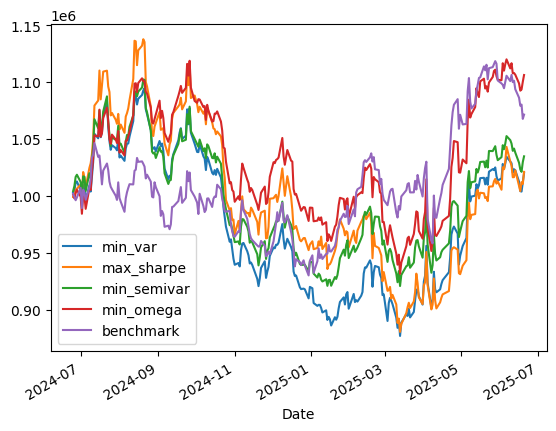

In [80]:
history.plot()
plt.show()

# 3) Selección de Estrategia de Inversión. (20%)

Utilizando los resultados de tu backtesting y las métricas de desempeño, selecciona una estrategia de inversión. Realiza una conclusión clara, breve y robusta de porque es la mejor estrategia PARA TI, apoyate en las métricas obtenidas y en tu perfil de aversión al riesgo.

## Metricas

In [81]:
returns_history = history.pct_change().dropna()

In [82]:
metrics = pd.DataFrame(index = history.columns)

risk_free = rf * 252

metrics["rendimiento_promedio"] = returns_history.mean() * 252 

metrics["Rendimiento_efectivo"] = (history.iloc[-1] / V0 - 1 )

metrics["Volatilidad"] = returns_history.std() * np.sqrt(252)

metrics["sharpe"] = (metrics.rendimiento_promedio - (risk_free)) /  metrics.Volatilidad

metrics["downside_risk"]  = returns_history[returns_history < 0].fillna(0).std() * np.sqrt(252)

metrics["upside_risk"]  = returns_history[returns_history > 0].fillna(0).std() * np.sqrt(252)

metrics["omega"] = metrics.upside_risk / metrics.downside_risk

metrics["betas"] = returns_history.cov()["benchmark"] / returns_history.cov()["benchmark"]["benchmark"]

metrics["alpha_jensen"] = metrics.rendimiento_promedio - (risk_free  + metrics.betas * (metrics["rendimiento_promedio"]["benchmark"] - risk_free))

metrics["treynor"] = (metrics.rendimiento_promedio - risk_free) / metrics.betas

metrics["sortino"] = (metrics.rendimiento_promedio - risk_free)/metrics.downside_risk

In [83]:
metrics.T

,min_var,max_sharpe,min_semivar,min_omega,benchmark
rendimiento_promedio,0.0306,0.0395,0.0427,0.1170,0.0810
Rendimiento_efectivo,0.0201,0.0211,0.0348,0.1063,0.0714
Volatilidad,0.1630,0.1856,0.1565,0.1731,0.1572
sharpe,-0.4532,-0.3502,-0.3946,0.0722,-0.1498
downside_risk,0.0959,0.1105,0.0933,0.1023,0.0926
upside_risk,0.0967,0.1104,0.0910,0.1042,0.0944
omega,1.0078,0.9986,0.9744,1.0191,1.0199
betas,0.7544,0.7474,0.7429,0.8141,1.0000
alpha_jensen,-0.0561,-0.0474,-0.0443,0.0317,0.0000
treynor,-0.0979,-0.0870,-0.0831,0.0154,-0.0235


## Conclusion

Desde mi punto de vista, y con base en mi perfil de riesgo considero que el portafolio con mejores metricas corresponde al portafolio de Max Omega. Esto dado que incluso cuando todos los demas portafolios hayan tenido una menor exposición al riesgo sistematico y cuenten con una menor volatilidad, los resultados del portafolios respecto de las medidas de rendimiento son muy superiores, habiendo incluso generado alpha cuando los demas portafolios asumiendo un ligero incremento en la beta del mismo, mientras que los otros portafolios en lugar de generar alpha tiene una alpha inferior a cero, lo que quiere decir que se encuentran sobrevalorados y por tanto no representan una verdadera oportunidad de inversión.

Por tanto considerando estos factores en el desempeño de los portafolios durante la ventana de back puedo considerar que el mejor portafolios para los siguientes periodos se encuetran definido por los pesos de la estrategia de max omega (min omega en el caso de optimizar usando minimize de scipy)

# 4) Calculo de Pesos para Portafolio Real.

En base a la estrategia de Asset Allocation seleccionada en el punto anterior, calcula los pesos eficientes y la cantidad de acciones que utilizarías para invertir en la realidad en tu portafolio. Recuerda tomar la ventana de datos más reciente, en función del horizonte temporal tomado. (10%)

En el entendido que la ventana de tiempo más reciente corresponde al periodo empieza a partir del 23 de marzo de 2025 hasta el 25 de marzo del 2026 para invertir en un portafolio en la realidad, se utilizara la estrategia de Max Omega para estimar los pesos del portafolios

In [84]:
start_real = "2025-03-23"
end_real = "2026-03-25"

prices_real = yf.download(tickers=tickers, start=start_real, end=end_real)["Close"]

returns_real = prices_real.pct_change().dropna()

/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[                       0%                       ]/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/home/rigodev/ITESO/06/portafolios/env/lib/python3.12/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a futur

In [85]:
returns_real

Ticker,CEMEXCPO.MX,CHDRAUIB.MX,CUERVO.MX,KOFUBL.MX,LABB.MX,LIVEPOLC-1.MX,RA.MX
Date,,,,,,,
2025-03-25,0.0353,0.0003,-0.0094,0.0175,0.0064,0.0236,0.0169
2025-03-26,-0.0428,0.0439,-0.0022,0.0128,-0.0116,-0.0156,-0.0033
2025-03-27,0.0157,-0.0158,0.0315,0.0203,0.0190,-0.0057,-0.0265
2025-03-28,-0.0546,-0.0322,0.0164,0.0156,0.0083,0.0099,-0.0324
2025-03-31,-0.0086,0.0019,0.0075,-0.0059,-0.0043,-0.0204,-0.0455
...,...,...,...,...,...,...,...
2026-03-18,-0.0155,0.0109,-0.0130,-0.0072,0.0194,0.0060,0.0090
2026-03-19,-0.0027,-0.0033,-0.0059,0.0138,-0.0815,-0.0008,-0.0199
2026-03-20,-0.0202,-0.0183,-0.0026,-0.0173,-0.0599,0.0370,-0.0106


In [86]:
def opt_max_omega(rets):
    n_assets = len(rets.columns)
    
    below_zero = rets[rets < 0].fillna(0)
    above_zero = rets[rets > 0].fillna(0)
    
    upside = np.array(above_zero.std())
    downside = np.array(below_zero.std())
    
    omegas = upside/downside
    
    omega = lambda w: -np.sum(w*omegas)
    
    w0 = np.ones(n_assets)/n_assets
    
    bounds = [(0.1,0.4)]*n_assets
    
    constraint = lambda w: sum(w)-1
    
    result = minimize(
        fun=omega, x0=w0, 
        bounds=bounds,
        constraints=
        {'fun': constraint, 
        'type': 'eq'
        }, 
        tol=1e-16)
    
    return result.x

In [87]:
weight_portfolio = opt_max_omega(rets=returns_real)

### Asignación de capital

In [89]:
dict(zip(returns_real.columns,weight_portfolio))

{'CEMEXCPO.MX': np.float64(0.10000000000000003),
 'CHDRAUIB.MX': np.float64(0.10000000000000005),
 'CUERVO.MX': np.float64(0.4),
 'KOFUBL.MX': np.float64(0.1),
 'LABB.MX': np.float64(0.10000000000000002),
 'LIVEPOLC-1.MX': np.float64(0.1),
 'RA.MX': np.float64(0.1)}